# HyperKvasir supervised fine-tuning (ViT + ResNet50)

Fine-tune stronger supervised baselines on the 23-class HyperKvasir dataset:
- ViT (transformers `ViTForImageClassification`, unfrozen)
- ResNet50 (torchvision, pre-trained ImageNet weights, replaced head) (Separated in another file present in the same directory)

Outputs are written to `2_supervised_finetuning/out/`.


In [1]:
import os
from pathlib import Path
import json
import random
from typing import Tuple

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import ViTForImageClassification, AutoImageProcessor

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True


In [2]:
# Paths & config
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root containing '0_dataset_prep'. cwd={start}")

DATA_ROOT = find_dataset_root()
META_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "metadata_enriched.csv"
LABEL_MAP_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "label_map.csv"
OUT_DIR = DATA_ROOT / "2_supervised_finetuning" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Choose model type: 'vit' or 'resnet'
MODEL_TYPE = 'vit'  # change to 'resnet' to run ResNet50
MODEL_NAME = "google/vit-base-patch16-224-in21k"  # used only for ViT

BATCH_SIZE = 16
NUM_WORKERS = 8  # set >0 if we want multiprocessing
EPOCHS = 3
LR = 2e-4
WEIGHT_DECAY = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Data root:", DATA_ROOT)
print("Output dir:", OUT_DIR)


Device: cuda
Data root: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir
Output dir: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/2_supervised_finetuning/out


In [3]:
# Load metadata
meta = pd.read_csv(META_CSV)
images_base = DATA_ROOT / "0_dataset_prep"

def to_abs(p):
    p = Path(p)
    if p.is_absolute():
        return p
    return (images_base / p).resolve()

meta["image_path"] = meta["image_path"].apply(lambda p: str(to_abs(p)))

if LABEL_MAP_CSV.exists():
    label_map = pd.read_csv(LABEL_MAP_CSV)
    id_to_name = dict(zip(label_map.label_id, label_map.label_name))
else:
    id_to_name = {i: name for i, name in enumerate(sorted(meta.label_name.unique()))}
name_to_id = {v: k for k, v in id_to_name.items()}
meta["label_id"] = meta["label_name"].map(name_to_id)

meta = meta[meta["image_path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)
print("After filtering images:", meta.shape)
print(meta["split"].value_counts())


After filtering images: (10662, 7)
split
train         8528
validation    1069
test          1065
Name: count, dtype: int64


In [4]:
# Dataset + transforms

# 224 is the default because both backbones are pre-trained on ImageNet at 224×224
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class ImageDS(Dataset):
    def __init__(self, df: pd.DataFrame, tfm):
        self.paths = df["image_path"].tolist()
        self.labels = df["label_id"].astype(int).tolist()
        self.tfm = tfm
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.tfm(img), self.labels[idx]


In [5]:
# Prepare splits
train_df = meta[meta["split"] == "train"].reset_index(drop=True)
val_df   = meta[meta["split"] == "validation"].reset_index(drop=True)
test_df  = meta[meta["split"] == "test"].reset_index(drop=True)

train_ds = ImageDS(train_df, train_tfms)
val_ds   = ImageDS(val_df, val_tfms)
test_ds  = ImageDS(test_df, val_tfms)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

NUM_CLASSES = len(id_to_name)
print({"train": len(train_ds), "val": len(val_ds), "test": len(test_ds), "classes": NUM_CLASSES})


{'train': 8528, 'val': 1069, 'test': 1065, 'classes': 23}


In [6]:
# Class weights to mitigate imbalance
class_counts = train_df["label_id"].value_counts().sort_index()
class_weights = torch.tensor((class_counts.sum() / (NUM_CLASSES * class_counts)).values, dtype=torch.float32).to(DEVICE)
print("Class weights shape", class_weights.shape)


Class weights shape torch.Size([23])


In [7]:
# Build model
def build_model(model_type: str):
    if model_type == 'vit':
        model = ViTForImageClassification.from_pretrained(
            MODEL_NAME,
            num_labels=NUM_CLASSES,
            id2label=id_to_name,
            label2id=name_to_id,
        )
    elif model_type == 'resnet':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_feats = model.fc.in_features
        model.fc = nn.Linear(in_feats, NUM_CLASSES)
    else:
        raise ValueError("MODEL_TYPE must be 'vit' or 'resnet'")
    return model.to(DEVICE)

model = build_model(MODEL_TYPE)
print(model.__class__.__name__)


/home/aristotle/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification


In [8]:
# Training helpers
def run_epoch(dataloader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss(weight=class_weights)
    for xb, yb in tqdm(dataloader, leave=False, desc="train" if is_train else "eval"):
        xb, yb = xb.to(DEVICE), torch.tensor(yb, device=DEVICE)
        if is_train:
            optimizer.zero_grad()
        if MODEL_TYPE == 'vit':
            out = model(xb, labels=yb)
            loss = out.loss
            logits = out.logits
        else:
            logits = model(xb)
            loss = ce(logits, yb)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(yb.detach().cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss, all_preds, all_labels

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


In [9]:
# Train
best_val_acc = -1
history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_pred, train_true = run_epoch(train_dl, model, optimizer)
    val_loss, val_pred, val_true = run_epoch(val_dl, model, optimizer=None)
    val_acc = (val_pred == val_true).mean()
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_acc": val_acc})
    print(f"Ep{epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), OUT_DIR / f"best_{MODEL_TYPE}.pt")

print("Best val acc:", best_val_acc)


train:   0%|          | 0/533 [00:00<?, ?it/s]

/tmp/ipykernel_556112/3591784277.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xb, yb = xb.to(DEVICE), torch.tensor(yb, device=DEVICE)


eval:   0%|          | 0/67 [00:00<?, ?it/s]

Ep1: train_loss=0.7619 val_loss=0.4421 val_acc=0.8466


train:   0%|          | 0/533 [00:00<?, ?it/s]

eval:   0%|          | 0/67 [00:00<?, ?it/s]

Ep2: train_loss=0.4100 val_loss=0.3946 val_acc=0.8756


train:   0%|          | 0/533 [00:00<?, ?it/s]

eval:   0%|          | 0/67 [00:00<?, ?it/s]

Ep3: train_loss=0.3349 val_loss=0.4121 val_acc=0.8616
Best val acc: 0.8755846585594013


In [10]:
# Evaluate on test set
model.load_state_dict(torch.load(OUT_DIR / f"best_{MODEL_TYPE}.pt", map_location=DEVICE))
model.eval()
_, test_pred, test_true = run_epoch(test_dl, model, optimizer=None)
report = classification_report(test_true, test_pred, labels=sorted(id_to_name.keys()), target_names=[id_to_name[i] for i in sorted(id_to_name)], output_dict=True, zero_division=0)
print("Test accuracy:", report["accuracy"])


eval:   0%|          | 0/67 [00:00<?, ?it/s]

/tmp/ipykernel_556112/3591784277.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xb, yb = xb.to(DEVICE), torch.tensor(yb, device=DEVICE)


Test accuracy: 0.8713615023474178


In [11]:
# Save artifacts
with open(OUT_DIR / f"metrics_{MODEL_TYPE}.json", "w") as f:
    json.dump(report, f, indent=2)
pd.DataFrame(history).to_csv(OUT_DIR / f"history_{MODEL_TYPE}.csv", index=False)

print("Saved metrics and history to", OUT_DIR)


Saved metrics and history to /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/2_supervised_finetuning/out


## Results summary

Overall:


,accuracy,macro_f1,weighted_f1
0,0.871362,0.524242,0.855874


Top-5 classes by F1:


,precision,recall,f1-score,support
cecum,0.970874,0.990099,0.980392,101.0
polyps,0.990000,0.961165,0.975369,103.0
bbps-0-1,0.969231,0.969231,0.969231,65.0
bbps-2-3,0.990909,0.947826,0.968889,115.0
retroflex-stomach,0.938272,1.000000,0.968153,76.0


Bottom-5 classes by F1:


,precision,recall,f1-score,support
ulcerative-colitis-grade-0-1,0.0,0.0,0.0,3.0
ulcerative-colitis-grade-1-2,0.0,0.0,0.0,1.0
ulcerative-colitis-grade-2-3,0.0,0.0,0.0,3.0
ulcerative-colitis-grade-3,0.0,0.0,0.0,13.0
barretts,0.0,0.0,0.0,4.0


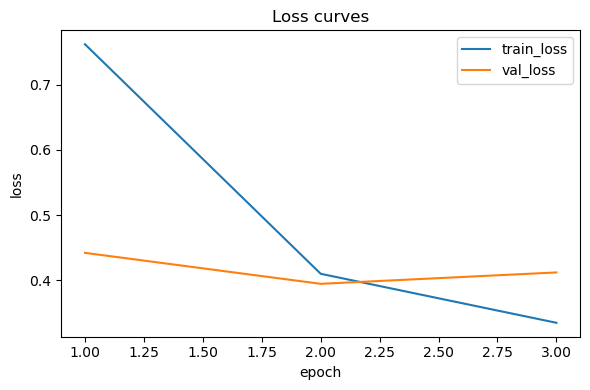

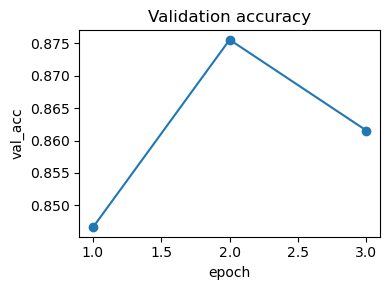

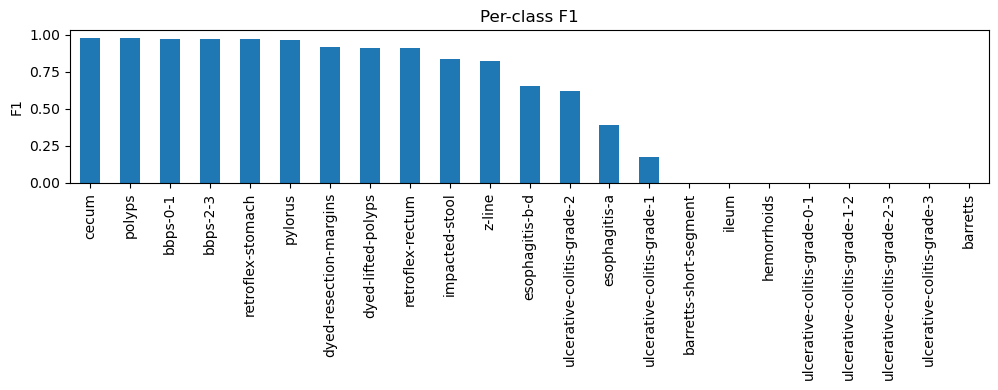

In [12]:
# Results summary & visuals
import json
import pandas as pd
import matplotlib.pyplot as plt

history_path = OUT_DIR / f"history_{MODEL_TYPE}.csv"
metrics_path = OUT_DIR / f"metrics_{MODEL_TYPE}.json"

hist = pd.read_csv(history_path) if history_path.exists() else None
with open(metrics_path) as f:
    metrics = json.load(f)

# Overall metrics table
overall = pd.DataFrame({
    "accuracy": [metrics.get("accuracy")],
    "macro_f1": [metrics.get("macro avg", {}).get("f1-score")],
    "weighted_f1": [metrics.get("weighted avg", {}).get("f1-score")],
})
print("Overall:")
display(overall)

# Per-class metrics
class_df = pd.DataFrame(metrics).T
class_df = class_df.drop(index=[idx for idx in ["accuracy", "macro avg", "weighted avg"] if idx in class_df.index])
class_df = class_df.sort_values("f1-score", ascending=False)

print("Top-5 classes by F1:")
display(class_df.head(5)[["precision", "recall", "f1-score", "support"]])
print("Bottom-5 classes by F1:")
display(class_df.tail(5)[["precision", "recall", "f1-score", "support"]])

# Training curves
if hist is not None:
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ax1.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    ax1.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss")
    ax1.legend()
    ax1.set_title("Loss curves")
    plt.tight_layout()
    plt.show()

    fig, ax2 = plt.subplots(figsize=(4, 3))
    ax2.plot(hist["epoch"], hist["val_acc"], marker="o")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("val_acc")
    ax2.set_title("Validation accuracy")
    plt.tight_layout()
    plt.show()

# Per-class F1 bar chart
fig, ax = plt.subplots(figsize=(10, 4))
class_df["f1-score"].plot(kind="bar", ax=ax)
ax.set_title("Per-class F1")
ax.set_ylabel("F1")
plt.tight_layout()
plt.show()
